# Portafolio de acciones - Prophet + backtesting

Descargamos **5 acciones** (desde 2010) con **yfinance**, armamos un portafolio equiponderado, entrenamos **Prophet** hasta 2023 y comparamos lo **real vs lo predicho** en **2024 a la fecha**.

| Sección | Tema |
|---------|------|
| **1** | Portafolio (5 tickers, train / test) |
| **2** | Prophet por acción y portafolio |
| **3** | Backtesting: real vs predicho + MAPE |


## ¿Qué es Prophet?

**Prophet no es una red neuronal.** Es un modelo de **series de tiempo** (Meta) para forecasting interpretable: descompone la serie en partes que puedes explicar.

```
y(t) ≈ tendencia + estacionalidad + festivos + ruido
```

| Pregunta | Respuesta corta |
|----------|-----------------|
| ¿Es deep learning? | **No.** No hay capas ni backprop. |
| ¿Cómo “entrena”? | Ajusta coeficientes con **Stan** (inferencia bayesiana / MAP). En código: `m.fit(train)` -> `m.predict(futuro)`. |
| ¿Qué aprende? | Pendiente de la tendencia (con quiebres), ondas de estacionalidad (Fourier) y efecto de festivos. |
| ¿Para qué sirve? | Métricas con patrón claro: ventas, tráfico, usuarios... En acciones funciona **limitado** (noticias y shocks no los modela). |

**Prophet vs red neuronal (LSTM, etc.)**

| | Prophet | Red neuronal |
|--|---------|----------------|
| Estructura | Fórmula fija (tendencia + Fourier) | Capas que aprenden representaciones |
| Datos | Pocos, serie regular en el tiempo | Muchos suelen ayudar |
| Interpretación | Alta | Baja (caja negra) |

En este notebook usamos **backtesting**: entrenamos con 2010-2023 y medimos qué tan bien Prophet reproduce **2024 -> hoy**. No es consejo de inversión - es práctica de forecasting.

## Setup

```bash
pip install prophet yfinance pandas matplotlib
```


In [1]:
#%pip install -q prophet yfinance pandas matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore")

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from prophet import Prophet

TICKERS = ["AAPL", "MSFT", "JPM", "XOM", "JNJ"]

INICIO = "2010-01-01"
FIN = date.today().strftime("%Y-%m-%d")
FECHA_CORTE = "2024-01-01"  # train: 2010-2023 | backtest: 2024 -> hoy

# Ajustes para acciones (el Prophet default queda muy plano)
PROPHET_KWARGS = dict(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",  # estacionalidad en % del nivel, no puntos fijos
    changepoint_prior_scale=0.5,  # default 0.05 = curva muy rigida
    changepoint_range=0.95,  # quiebres hasta casi el final del train
)


def crear_prophet():
    m = Prophet(**PROPHET_KWARGS)
    m.add_country_holidays("US")
    return m


Importing plotly failed. Interactive plots will not work.


## 1 - Portafolio equiponderado

Esta celda prepara los datos **antes** de Prophet. Va en 5 pasos:

### Paso 1 - Descargar precios (`yf.download`)

```python
precios = yf.download(TICKERS, start=INICIO, end=FIN)["Close"].dropna()
```

- **`TICKERS`**: las 5 acciones (`AAPL`, `MSFT`, ...).
- **`["Close"]`**: solo el precio de **cierre** de cada día bursátil.
- **Resultado `precios`**: tabla con una columna por acción y una fila por fecha.

### Paso 2 - El índice en 100 (normalizar)

```python
normalizado = precios / precios.iloc[0] * 100
portafolio = normalizado.mean(axis=1)
```

#### ¿Qué problema resolvemos?

En dólares crudos, las acciones no son comparables:

| Acción | Precio día 1 (ejemplo) |
|--------|------------------------|
| AAPL | $30 |
| JPM | $150 |

Si promedias $30 y $150 -> **$90**, y el portafolio estaría **dominado por JPM** (la cara). No es “20% en cada una”.

#### La fórmula, línea por línea

```python
normalizado = precios / precios.iloc[0] * 100
```

| Parte | Significado |
|-------|-------------|
| `precios.iloc[0]` | Precio de **cada** acción en el **primer día** del histórico (fila 0). |
| `precios / precios.iloc[0]` | “¿Cuántas veces el precio de hoy respecto al día 1?” -> el día 1 vale **1.0**; si subió 10%, vale **1.10**. |
| `* 100` | Reescala para leerlo como **índice**: el día 1 = **100** (como el IPC o el S&P rebasado). |

**No cambia el rendimiento %** - solo cambia la escala numérica.

#### Ejemplo numérico (2 acciones)

| Día | AAPL ($) | JPM ($) | AAPL índice | JPM índice |
|-----|----------|---------|-------------|------------|
| 1 | 30 | 150 | 30/30×100 = **100** | 150/150×100 = **100** |
| 2 | 33 (+10%) | 165 (+10%) | 33/30×100 = **110** | 165/150×100 = **110** |
| 3 | 27 (−10% vs día 1) | 135 (−10%) | 27/30×100 = **90** | 135/150×100 = **90** |

Las dos **arrancan en 100** y suben/bajan según **su propio** % de rendimiento, no según cuántos dólares cueste la acción.

#### Portafolio equiponderado

```python
portafolio = normalizado.mean(axis=1)
```

Cada día: **promedio** de las 5 columnas ya normalizadas.

Con el ejemplo de arriba, día 2: `(110 + 110) / 2 = 110` -> las dos subieron 10%, el portafolio también.

**Interpretación:** “Si invertí **igual peso** en cada acción el primer día y dejé correr el rendimiento, ¿cuánto valdría mi índice hoy?” - empezando en 100.

#### ¿Por qué índice / rendimiento y no precios en dólares?

| Si usáramos **precios crudos** | Problema |
|--------------------------------|----------|
| Promediar AAPL ($30) y JPM ($150) | El portafolio refleja sobre todo la acción **cara**, no “20% en cada una”. |
| Graficar 5 acciones juntas | Una línea domina la escala; las baratas parecen planas aunque suban mucho en %. |
| Entrenar Prophet con niveles muy distintos | El modelo ve **magnitudes** ($ vs $$$); comparar MAPE entre tickers es confuso. |
| Crecimiento real de las acciones | Suele ser **multiplicativo** (+10%, +10%...) - el **índice** (o el log después) captura eso mejor que “sumar dólares”. |

| Con **índice en 100** | Ventaja |
|-----------------------|---------|
| Todas las series empiezan igual | Comparas **quién rindió más** desde 2010, no quién cuesta más hoy. |
| Promedio del portafolio | Tiene sentido: mismo peso en cada acción al inicio. |
| Más adelante usamos `log(y)` | El log convierte “crecer en %” en algo casi lineal - estándar en finanzas para series de precios. |

**En una frase:** no nos importa tanto “¿Apple cuesta $200?” sino “¿cuánto **cambió** desde el inicio respecto a las demás?”. El índice 100 es esa respuesta en una sola escala.

> **Nota:** Prophet *podría* entrenarse con precios crudos de **una sola** acción; el notebook normaliza porque armamos **portafolio** y comparamos **varias** series en la misma gráfica y en MAPE.

### Paso 3 - Formato Prophet (`a_prophet`)

Prophet solo entiende dos columnas:

| Columna | Significado |
|---------|-------------|
| **`ds`** | fecha (datetime) |
| **`y`** | valor numérico a predecir (aquí: el **índice** 100, 110, 90...) |

`a_prophet(serie)` convierte una serie de pandas en ese formato y quita zona horaria (`tz_localize(None)`) para evitar errores al mezclar fechas.

### Paso 4 - Diccionario `datos`

Guardamos **6 series**: las 5 acciones + `PORTAFOLIO`. Cada una ya está en formato `ds` / `y`.

### Paso 5 - Train vs test (backtesting)

```python
train = ... # ds < 2024-01-01 -> Prophet SÍ entrena con esto
test = ... # ds >= 2024-01-01 -> Prophet NO lo ve al entrenar; solo para evaluar
```

| Conjunto | Fechas | Uso |
|----------|--------|-----|
| **`train`** | 2010 -> dic 2023 | Ajustar el modelo |
| **`test`** | 2024 -> hoy | Comparar predicción vs realidad |

El `print` y `tail(3)` al final solo **confirman** el periodo y muestran las últimas filas del portafolio (un `y` de ~1600 = “el índice creció ~16× desde 100 en 2010”, no son dólares).


In [3]:
# 1) Precios de cierre diarios (tabla: fechas x tickers)
precios = yf.download(TICKERS, start=INICIO, end=FIN, progress=False)["Close"].dropna()

# 2) Cada accion empieza en 100 -> comparamos rendimiento, no precio en $
normalizado = precios / precios.iloc[0] * 100
portafolio = normalizado.mean(axis=1)  # promedio = 20% en cada una

# 3) Serie pandas -> DataFrame con columnas ds (fecha) y y (valor) para Prophet
def a_prophet(serie):
    df = serie.reset_index()
    df.columns = ["ds", "y"]
    df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)
    return df

# 4) Un DataFrame por accion + uno para el portafolio
datos = {t: a_prophet(precios[t]) for t in TICKERS}
datos["PORTAFOLIO"] = a_prophet(portafolio)

# 5) Partir en entrenamiento (hasta 2023) y backtest (2024 en adelante)
train = {k: v[v["ds"] < FECHA_CORTE].copy() for k, v in datos.items()}
test = {k: v[v["ds"] >= FECHA_CORTE].copy() for k, v in datos.items()}

print(f"Periodo: {INICIO} -> {FIN} | train antes de {FECHA_CORTE} | backtest desde {FECHA_CORTE}")
print(f"Dias train: {len(train['AAPL'])} | dias test: {len(test['AAPL'])}")
datos["PORTAFOLIO"].tail(3)  # ultimas fechas del portafolio


Periodo: 2010-01-01 → 2026-07-01 | train antes de 2024-01-01 | backtest desde 2024-01-01
Días train: 3522 | días test: 625


,ds,y
4144,2026-06-26,1643.035798
4145,2026-06-29,1634.755565
4146,2026-06-30,1659.033694


### ¿Cómo quedan guardadas las series? (dict, no tensor)

**No es una red neuronal** y **no es un tensor**. Usamos **Prophet** (modelo de series de tiempo con fórmulas + Stan). Cada serie se entrena **por separado**.

#### Estructura en memoria

Todo vive en **diccionarios de Python** (`dict`). Cada valor es un **DataFrame de pandas** (tabla de 2 columnas):

```
datos = {
 "AAPL": DataFrame con columnas ds | y (~4000 filas, una por día)
 "MSFT": DataFrame con columnas ds | y
 "JPM": ...
 "XOM": ...
 "JNJ": ...
 "PORTAFOLIO": DataFrame con columnas ds | y ← promedio de las 5
}
```

Ejemplo conceptual de **una** entrada (`datos["AAPL"]`):

| ds | y |
|----|---|
| 2010-01-04 | 100.0 |
| 2010-01-05 | 101.2 |
| ... | ... |

`train` y `test` tienen **la misma forma**: otro `dict` con las mismas 6 llaves, pero cada DataFrame recortado por fecha.

#### ¿Cuál usamos para entrenar? ¿Todos?

**Sí entrenamos las 6**, pero **no juntas en un solo modelo**. Más adelante verás:

```python
predicciones = {}
for nombre in ["AAPL", "MSFT", "JPM", "XOM", "JNJ", "PORTAFOLIO"]:
 _, _, predicciones[nombre] = entrenar_prophet(train[nombre], test[nombre])
```

Eso significa:

| Iteración | Entrada | Qué pasa |
|-----------|---------|----------|
| 1 | `train["AAPL"]` | Prophet **solo** con fechas y precios de Apple -> 1 modelo AAPL |
| 2 | `train["MSFT"]` | Otro Prophet **independiente** para Microsoft |
| ... | ... | ... |
| 6 | `train["PORTAFOLIO"]` | Otro Prophet para el **índice** del portafolio |

 -> **6 modelos Prophet distintos**, cada uno con su propia curva de tendencia. No hay una sola “red” que reciba las 5 acciones a la vez.

#### ¿Y `predicciones`?

Otro `dict`. Cada llave (`"AAPL"`, ..., `"PORTAFOLIO"`) apunta a un DataFrame con fechas del backtest y columnas como `y` (real), `yhat` (predicho), `yhat_lower`, `yhat_upper`.

#### Resumen en una frase

**Empaquetado:** `dict` -> `str` (nombre) -> `DataFrame` (`ds`, `y`). **Entrenamiento:** un Prophet por ticker + uno para portafolio. **No** tensor, **no** deep learning.

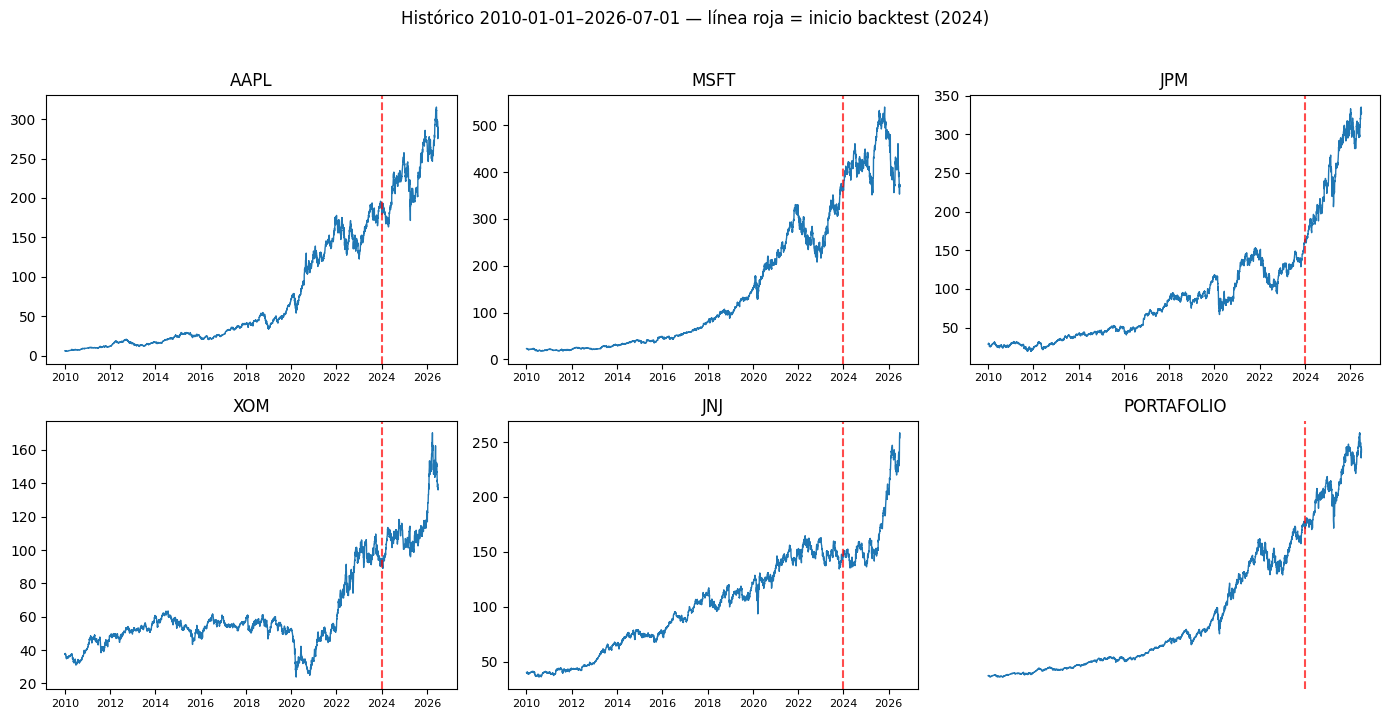

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, nombre in enumerate(list(TICKERS) + ["PORTAFOLIO"]):
    ax = axes[i]
    df = datos[nombre]
    ax.plot(df["ds"], df["y"], linewidth=1)
    ax.axvline(pd.to_datetime(FECHA_CORTE), color="red", linestyle="--", alpha=0.7)
    ax.set_title(nombre)
    ax.tick_params(axis="x", labelsize=8)

axes[-1].axis("off")
fig.suptitle(f"Historico {INICIO}-{FIN} - linea roja = inicio backtest (2024)", y=1.02)
plt.tight_layout()
plt.show()


### Cómo leer las 6 mini-gráficas de arriba

Cada panel muestra el precio **normalizado a 100** al inicio de 2010 (no son dólares absolutos - son **rendimientos comparables**).

| Panel | Qué ves |
|-------|---------|
| **AAPL, MSFT, ...** | Evolución de **cada acción** por separado |
| **PORTAFOLIO** | Promedio de las 5 -> línea más **suave** que una sola acción |

**Para qué sirve:** ver si las series tienen **tendencia** (suben en el largo plazo) y **volatilidad** (subidas/bajadas). Prophet asume que esos patrones del pasado continúan - en acciones eso solo es **parcialmente** cierto.

La línea vertical roja (si aparece en tu versión) o el corte mental en **2024** separa lo que usamos para **entrenar** de lo que usamos para **evaluar**.


## 2 - Prophet (train 2010-2023)

El Prophet **por defecto** suele quedar **muy plano** en acciones: predice algo casi recto y **subestima** rallies fuertes (como 2024-2025). Por eso no usamos el default tal cual.

### Qué hicimos distinto (resumen)

| Ajuste | En una frase | Por qué en acciones |
|--------|--------------|---------------------|
| **`log(y)`** | Modelamos el **logaritmo** del precio, no el precio crudo | Las acciones suelen crecer en **%** (duplicar de 100 -> 200 es como de 1000 -> 2000 en proporción). El log convierte eso en algo más lineal. |
| **`changepoint_prior_scale=0.5`** | Tendencia **más flexible** (default `0.05`) | Permite que la recta de tendencia **cambie de pendiente** varias veces y siga rallies recientes. Ver explicación abajo. |
| **`changepoint_range=0.95`** | Quiebres hasta el **95%** del train | Deja que la tendencia se ajuste también al final de 2023 (cerca del corte con 2024). |
| **`seasonality_mode='multiplicative'`** | La estacionalidad **escala** con el nivel | Un patrón de ±2% en 2020 pesa distinto que el mismo % en 2024 si el precio ya subió mucho. |
| **Festivos US** | Días sin bolsa | Evita que Prophet trate feriados como “caídas raras” de la serie. |

Entrenamos un modelo **por acción** y otro para el **portafolio**. El backtest (lo que no vio al entrenar) es **2024 -> hoy**.


### Hiperparámetros - explicados sin jerga

Prophet descompone la serie así:

```
valor ≈ tendencia + estacionalidad + festivos + ruido
```

En código usamos:

```python
Prophet(
 daily_seasonality=False,
 weekly_seasonality=True,
 yearly_seasonality=True,
 seasonality_mode="multiplicative",
 changepoint_prior_scale=0.5,
 changepoint_range=0.95,
)
m.add_country_holidays("US")
# entrenamos con y = log(precio); al predecir hacemos exp() para volver a escala real
```

---

### ¿Qué es un **changepoint** (punto de quiebre)?

Prophet **no** ajusta una sola recta a todo el histórico. Divide el tiempo en tramos: en cada tramo la **tendencia es casi una recta**, y en fechas especiales la recta **puede cambiar de pendiente**.

Esa fecha especial es un **changepoint**.

**Analogía:** imagina una regla que va siguiendo el precio en el tiempo. En un changepoint puedes **doblar** un poco la regla (más pendiente = rally; menos = corrección). Entre changepoint y changepoint la regla queda recta.

- Prophet coloca varios changepoints **candidatos** a lo largo del train (por default, ~25).
- No todos “activan” un quiebre fuerte: eso lo controla `changepoint_prior_scale`.

---

### `changepoint_prior_scale` - ¿qué tan flexible es la tendencia?

| Valor | Efecto visual | Cuándo usarlo |
|-------|---------------|---------------|
| **Bajo** (`0.05`, default) | Curva **muy suave**, casi una sola recta | Series estables, poco volátiles |
| **Medio** (`0.5`, lo usamos aquí) | La tendencia **puede curvarse** y seguir rallies o caídas recientes | Acciones con cambios de régimen (COVID, rally 2024...) |
| **Alto** (`>1`) | La curva **pegada al ruido** del día a día | Riesgo de **sobreajuste**; mal para pronosticar |

**Interpretación:** no es “prioridad” en sentido de importancia, es un **parámetro de regularización** (prior bayesiano). Le dice al modelo: *“¿cuánto puede cambiar la pendiente en cada changepoint?”*. Bajo = castiga cambios bruscos -> curva rígida. Alto = permite muchos quiebres -> curva nerviosa.

**En tu gráfica:** si la línea naranja (Prophet) va **más abajo** que la azul (real) después de 2024, a menudo significa que la tendencia quedó **demasiado conservadora** (prior bajo o pocos quiebres cerca del corte).

---

### `changepoint_range` - ¿dónde se permiten quiebres?

| Valor | Significado |
|-------|-------------|
| `0.8` (default) | Changepoints solo en el **primer 80%** del train. El último 20% queda “fijo” -> evita sobreajustar el final justo antes de predecir. |
| `0.95` (lo usamos) | Quiebres hasta el **95%** del train -> la tendencia puede adaptarse también a **finales de 2023**, útil si 2024 arranca fuerte. |


### `seasonality_mode='multiplicative'` - estacionalidad en % o en puntos?

Prophet modela la serie asi:

```
valor ~ tendencia x (1 + efecto_estacional)   # multiplicative
valor ~ tendencia + efecto_estacional         # additive (default)
```

**Additive (suma puntos fijos):** en enero siempre resta, digamos, **5 puntos** al indice, estes en 100 o en 1500.

**Multiplicative (multiplica por un factor):** en enero el patron es, por ejemplo, **-2%** respecto a la tendencia. Si el indice va en 100, baja ~2; si va en 1500, baja ~30.

| Modo | Formula intuitiva | Ejemplo (enero -2%) |
|------|-------------------|---------------------|
| `additive` | tendencia **+** onda fija | siempre ~-2 puntos |
| `multiplicative` | tendencia **x** factor | -2% del nivel actual |

**Por que en acciones:** el portafolio crece en **%**. La estacionalidad suele acompanar ese crecimiento, no quedarse fija en puntos.

---

### Tabla de parámetros (referencia rápida)

#### Tendencia

| Parámetro | Default | Qué hace (en llano) |
|-----------|---------|---------------------|
| `growth` | `'linear'` | Forma global: `'linear'` crece sin tope; `'logistic'` crece y se aplana (necesitas `cap`); `'flat'` sin tendencia. |
| `changepoints` | `None` | Fechas **fijas** donde forzar quiebres. `None` = Prophet las reparte automáticamente. |
| `n_changepoints` | `25` | Cuántos **candidatos** a changepoint hay en el histórico (no todos se notan igual de fuerte). |
| `changepoint_range` | `0.8` | % del train donde **sí** puede haber quiebres (ver arriba). |
| `changepoint_prior_scale` | `0.05` | Qué tan **flexible** es la pendiente en cada quiebre (ver arriba). |

#### Estacionalidad

| Parámetro | Default | Qué hace (en llano) |
|-----------|---------|---------------------|
| `yearly_seasonality` | `'auto'` | Patrones que se repiten **cada año** (ej. ciertos meses). |
| `weekly_seasonality` | `'auto'` | Patrones por **día de la semana** (lunes vs viernes). |
| `daily_seasonality` | `'auto'` | Patrones **dentro del día**. Con datos **diarios** pon `False` - solo hay un precio por día. |
| `seasonality_mode` | `'additive'` | `'additive'`: el efecto estacional **suma** puntos. `'multiplicative'`: **multiplica** (crece con el nivel del precio). |
| `seasonality_prior_scale` | `10.0` | Flexibilidad de las ondas estacionales (alto = más pegadas a la serie). |

#### Festivos e incertidumbre

| Parámetro | Qué hace (en llano) |
|-----------|---------------------|
| `holidays` / `add_country_holidays()` | Efecto puntual en días feriados (bolsa cerrada, etc.). |
| `interval_width` | Ancho del **intervalo de confianza** en la gráfica (0.80 = banda del 80%). |
| `yhat_lower` / `yhat_upper` | Límite inferior y superior de esa banda en el DataFrame de predicción. |

> **Prueba en clase:** baja `changepoint_prior_scale` a `0.05`, vuelve a correr la gráfica y compara: la naranja debería quedar **más plana** y suele **peor** en 2024-2025.


In [5]:
def entrenar_prophet(train_df, test_df):
    """Entrena un Prophet con log(y), predice y devuelve (modelo, prediccion completa, solo backtest)."""
    # Modelo nuevo con hiperparametros de PROPHET_KWARGS + festivos US
    m = crear_prophet()

    # Copia del train para no modificar el original
    tr = train_df.copy()
    # log(y): las acciones crecen en %; en log eso se ve mas lineal para Prophet
    tr["y"] = np.log(tr["y"])
    # Ajusta tendencia + estacionalidad solo con fechas < 2024
    m.fit(tr)

    # Genera fechas futuras: len(test_df) dias calendario despues del ultimo train
    pred = m.predict(m.make_future_dataframe(periods=len(test_df)))
    # Volvemos a escala del indice (exp deshace el log)
    for col in ("yhat", "yhat_lower", "yhat_upper"):
        pred[col] = np.exp(pred[col])

    # Solo dias bursatiles (yfinance no tiene sab/dom). Sin esto, Prophet inventa
    # yhat ~4 en fines de semana y yhat_lower ~0 -> fill_between pinta un bloque falso.
    fechas_bolsa = pd.concat([train_df[["ds"]], test_df[["ds"]]]).drop_duplicates()
    pred = pred.merge(fechas_bolsa, on="ds", how="inner")

    # Solo filas del backtest: une prediccion con valores reales por fecha (ds)
    eval_df = pred.merge(test_df, on="ds", how="inner")
    return m, pred, eval_df


# Un modelo Prophet por ticker + uno para PORTAFOLIO (6 en total)
predicciones = {}
for nombre in list(TICKERS) + ["PORTAFOLIO"]:
    _, _, predicciones[nombre] = entrenar_prophet(train[nombre], test[nombre])

predicciones["PORTAFOLIO"][["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].head()


22:17:36 - cmdstanpy - INFO - Chain [1] start processing
22:17:37 - cmdstanpy - INFO - Chain [1] done processing
22:17:38 - cmdstanpy - INFO - Chain [1] start processing
22:17:39 - cmdstanpy - INFO - Chain [1] done processing
22:17:39 - cmdstanpy - INFO - Chain [1] start processing
22:17:40 - cmdstanpy - INFO - Chain [1] done processing
22:17:41 - cmdstanpy - INFO - Chain [1] start processing
22:17:42 - cmdstanpy - INFO - Chain [1] done processing
22:17:42 - cmdstanpy - INFO - Chain [1] start processing
22:17:44 - cmdstanpy - INFO - Chain [1] done processing
22:17:44 - cmdstanpy - INFO - Chain [1] start processing
22:17:45 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat,yhat_lower,yhat_upper
0,2024-01-02,1129.166513,1135.694837,1079.916001,1193.575619
1,2024-01-03,1125.032108,1135.916203,1079.309882,1199.853999
2,2024-01-04,1115.702819,1135.737869,1078.305438,1196.636775
3,2024-01-05,1114.252500,1134.823184,1078.649361,1194.651343
4,2024-01-08,1132.861343,1135.176808,1078.398891,1197.047023


22:17:46 - cmdstanpy - INFO - Chain [1] start processing
22:17:47 - cmdstanpy - INFO - Chain [1] done processing


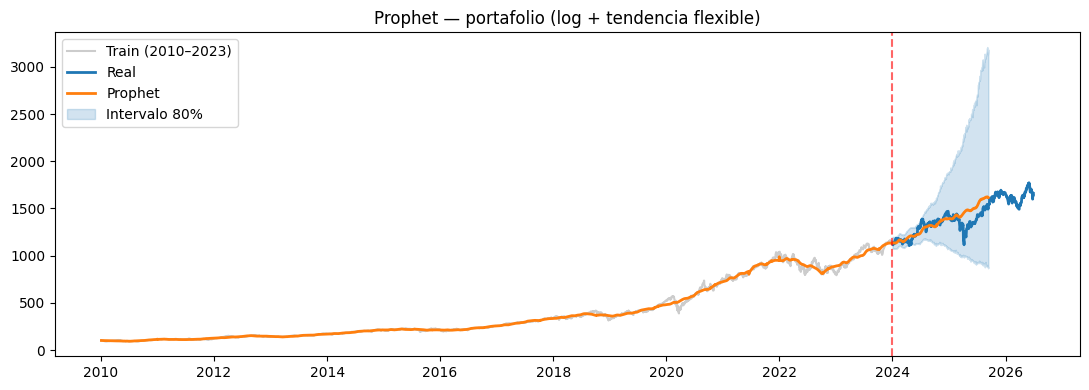

In [6]:
# Grafica del portafolio (pred_full ya viene sin fines de semana falsos)
_, pred_full, _ = entrenar_prophet(train["PORTAFOLIO"], test["PORTAFOLIO"])

corte = pd.to_datetime(FECHA_CORTE)
futuro = pred_full["ds"] >= corte

plt.figure(figsize=(11, 4))
plt.plot(train["PORTAFOLIO"]["ds"], train["PORTAFOLIO"]["y"], color="gray", alpha=0.4, label="Train (2010-2023)")
plt.plot(test["PORTAFOLIO"]["ds"], test["PORTAFOLIO"]["y"], color="tab:blue", label="Real", linewidth=2)
plt.plot(pred_full["ds"], pred_full["yhat"], color="tab:orange", label="Prophet", linewidth=2)
plt.fill_between(
    pred_full.loc[futuro, "ds"],
    pred_full.loc[futuro, "yhat_lower"],
    pred_full.loc[futuro, "yhat_upper"],
    color="tab:blue",
    alpha=0.2,
    label="Intervalo 80%",
)
plt.axvline(corte, color="red", linestyle="--", alpha=0.6)
plt.title("Prophet - portafolio (log + tendencia flexible)")
plt.legend()
plt.tight_layout()
plt.show()


### Cómo leer la gráfica anterior (portafolio)

Cada elemento responde una pregunta distinta:

| En la gráfica | Nombre | Qué significa |
|---------------|--------|---------------|
| Línea **gris** | Train (2010-2023) | Datos que Prophet **sí vio** al entrenar. |
| Línea **azul** | Real | Valor **verdadero** del portafolio (incluye 2024 en adelante). |
| Línea **naranja** | Prophet (`yhat`) | Lo que el modelo **predice** (ajuste en el pasado + pronóstico en 2024+). |
| Banda **azul clara** | Intervalo 80% | Rango donde el modelo cree que estará el precio con ~80% de probabilidad. **Más ancha** = **más incertidumbre**. |
| Línea **roja punteada** | Corte 2024-01-01 | A la **izquierda** entrenamiento; a la **derecha** backtest (el modelo **no** entrenó con esas fechas). |

#### Lectura paso a paso

1. **Izquierda del corte (gris):** la naranja debería **seguir** la gris. Si va muy abajo o muy plana, la tendencia quedó rígida o faltó `log(y)` / changepoints.
2. **Derecha del corte (azul vs naranja):** aquí mides si el modelo **anticipó** 2024-2025. Si el azul sube más rápido que la naranja -> **subestimó** el rally (común en acciones).
3. **Banda que se ensancha:** es **normal**. Cuanto más lejos pronosticas, más dudas el modelo (más escenarios posibles).
4. **Banda azul clara (después de 2024):** es el **intervalo 80%** (`yhat_lower` -> `yhat_upper`). Si veías un bloque sólido hasta el eje, era porque Prophet predice **todos los días calendario** (incluidos sáb/dom) y en fines de semana `yhat_lower` caía ~0. El código ahora filtra solo **días bursátiles** como yfinance.

#### Qué NO concluir

- Que la naranja “acierte” en 2024 **no** garantiza que acertará en 2025-2026.
- Prophet **no** lee noticias, tasas ni earnings - solo patrones numéricos del pasado.


## 3 - Backtesting (2024 -> hoy)

Ahora medimos **solo** el tramo que el modelo **no vio** al entrenar (desde `2024-01-01`).

| Columna | Significado |
|---------|-------------|
| `y` | Valor **real** del portafolio o acción ese día |
| `yhat` | Valor **predicho** por Prophet ese mismo día |
| `yhat_lower` / `yhat_upper` | Borde inferior / superior del intervalo del 80% |

**Métrica: MAPE** = error porcentual medio absoluto entre `y` y `yhat`. **Más bajo = mejor ajuste** en ese periodo.

```
MAPE = promedio( |real − predicho| / |real| ) × 100
```

Ejemplo: MAPE = 15% -> en promedio el modelo se equivocó ~15% del valor real en cada día del backtest.


In [7]:
def mape(real, predicho):
    return (abs((real - predicho) / real)).mean() * 100


tabla = []
for nombre, ev in predicciones.items():
    tabla.append({"activo": nombre, "MAPE %": round(mape(ev["y"], ev["yhat"]), 2)})

pd.DataFrame(tabla).sort_values("MAPE %")


,activo,MAPE %
5,PORTAFOLIO,4.97
0,AAPL,7.24
4,JNJ,9.29
3,XOM,12.15
2,JPM,19.30
1,MSFT,24.94


### ¿Qué significa la tabla de MAPE?

Cada fila es **una acción** (o el portafolio). El número es el **MAPE en 2024 -> hoy**.

| MAPE | Interpretación |
|------|----------------|
| **< 10%** | Prophet siguió bien la serie en ese periodo |
| **10-20%** | Error moderado - útil para comparar tickers entre sí |
| **> 20%** | Difícil de predecir: sector volátil, shock macro, cambio de régimen |

**Por qué cambian tanto los números** si tocas hiperparámetros:
- `changepoint_prior_scale` bajo -> curva plana -> MAPE alto si hubo rally.
- Sin `log(y)` -> subestima crecimiento exponencial.
- Festivos mal puestos -> ruido en días específicos.

**Lectura típica en este notebook:**
- **Portafolio / JNJ / AAPL** suelen tener MAPE más bajo si la tendencia reciente fue **continua**.
- **JPM / XOM / MSFT** a veces empeoran: banca, energía y tech tuvieron movimientos fuertes en 2024-2025 que un Prophet genérico no “adivina” solo con precios pasados.

> MAPE bajo en backtest **no** es ganancia futura garantizada. Solo dice qué tan bien **reprodujo el pasado reciente** que ya conoces para comparar modelos y parámetros.


### Real vs Prophet - portafolio (solo backtest)

La gráfica de abajo **hace zoom** en 2024 -> hoy (ya no muestra el train gris).

| Línea | Qué mirar |
|-------|-----------|
| **Azul (Real)** | Lo que **pasó** de verdad en bolsa |
| **Naranja (Prophet)** | Lo que el modelo **habría dicho** día a día si solo conociera hasta 2023 |
| **Banda** | Si el azul **sale** de la banda a menudo, el intervalo de confianza era **optimista** (muy estrecho) |

**Distancia vertical** entre azul y naranja = error del día. Si la naranja va sistemáticamente **debajo**, el modelo fue **pesimista** (subestimó la subida).


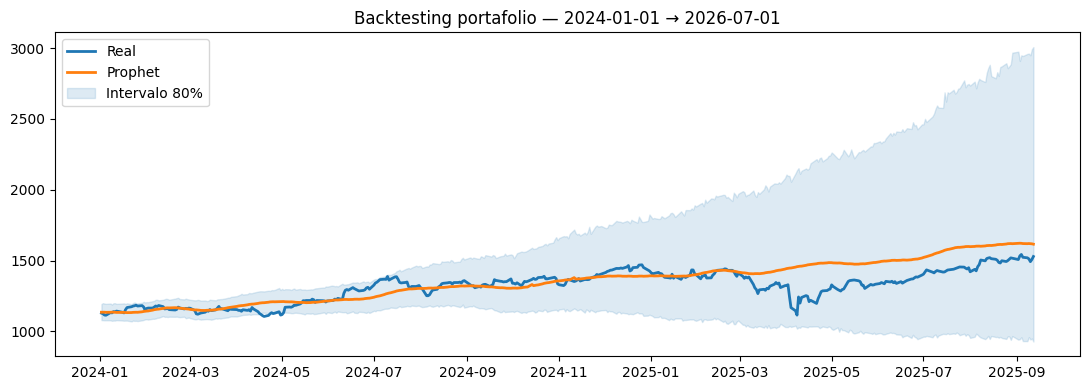

In [8]:
ev = predicciones["PORTAFOLIO"]

plt.figure(figsize=(11, 4))
plt.plot(ev["ds"], ev["y"], color="tab:blue", label="Real", linewidth=2)
plt.plot(ev["ds"], ev["yhat"], color="tab:orange", label="Prophet", linewidth=2)
plt.fill_between(
    ev["ds"], ev["yhat_lower"], ev["yhat_upper"],
    color="tab:blue", alpha=0.15, label="Intervalo 80%",
)
plt.title(f"Backtesting portafolio - {FECHA_CORTE} -> {FIN}")
plt.legend()
plt.tight_layout()
plt.show()


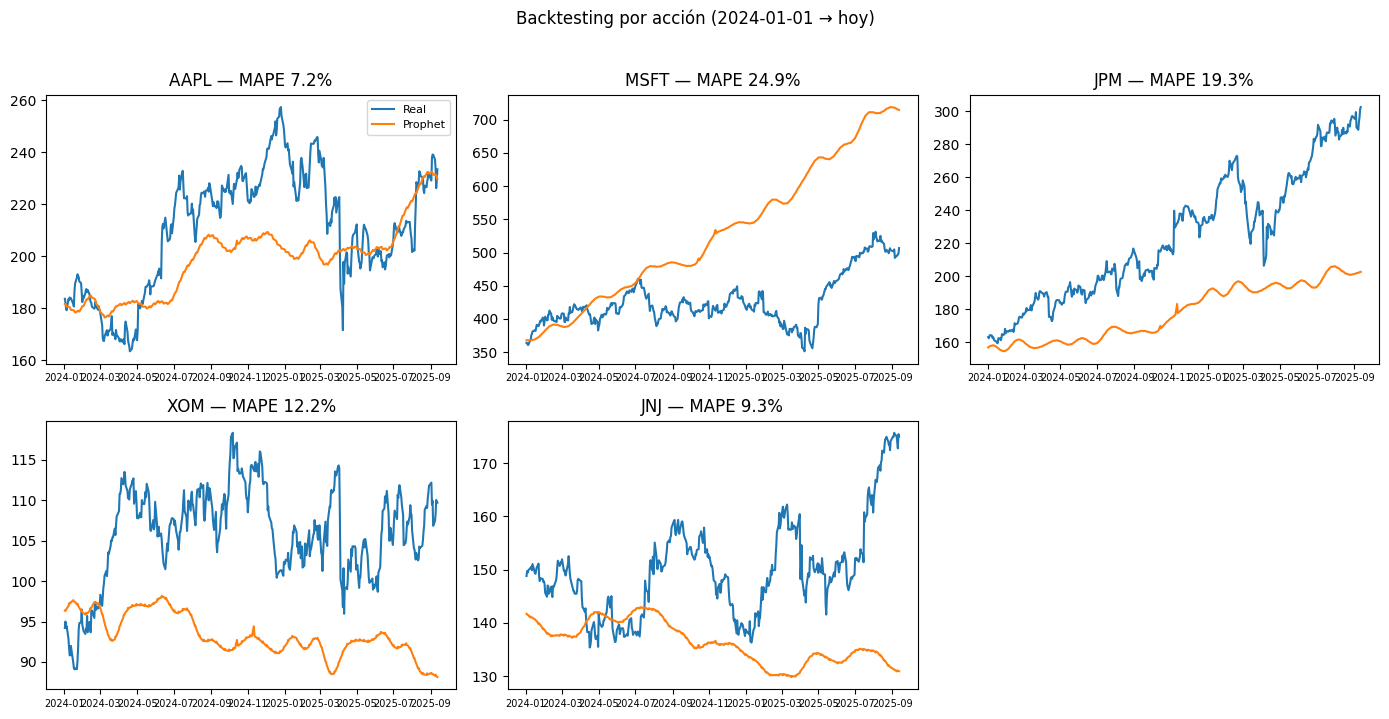

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, nombre in enumerate(TICKERS):
    ev = predicciones[nombre]
    ax = axes[i]
    ax.plot(ev["ds"], ev["y"], label="Real", linewidth=1.5)
    ax.plot(ev["ds"], ev["yhat"], label="Prophet", linewidth=1.5)
    ax.set_title(f"{nombre} - MAPE {mape(ev['y'], ev['yhat']):.1f}%")
    ax.tick_params(axis="x", labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle(f"Backtesting por accion ({FECHA_CORTE} -> hoy)", y=1.02)
plt.tight_layout()
plt.show()


**Cierre.** Portafolio equiponderado de 5 acciones, entrenamiento 2010-2023, backtesting **2024 a la fecha**.

**Ideas clave para llevar:**
1. Prophet separa **tendencia**, **estacionalidad** y **festivos** - puedes inspeccionar cada parte con `m.plot_components()`.
2. Los **changepoints** son fechas donde la tendencia **cambia de pendiente**; `changepoint_prior_scale` controla qué tan brusco puede ser ese cambio.
3. Las gráficas se leen **antes y después del corte 2024**: ajuste vs pronóstico.
4. MAPE resume el error en el backtest; sirve para **comparar** tickers y parámetros, no para invertir a ciegas.

Prueba cambiar `TICKERS`, `FECHA_CORTE`, `changepoint_prior_scale` (0.05 vs 0.5) y vuelve a graficar.
